# FL Privacy Tampering Experiment on `transaction_data.csv`

This notebook runs a transaction-data adaptation of `fl_privacy_tampering` and visualizes privacy leakage behavior.

It includes:
- baseline comparison (**attack off** vs **attack on**)
- tampering strength sweep
- visualizations for exposure gap, target rank, and membership inference AUC

In [1]:
import os
import sys
import copy
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)

# Make FL-Privacy-Leakage package importable from repo root.
sys.path.append(os.path.abspath("FL-Privacy-Leakage"))

In [2]:
from fl_privacy_tampering.federated import AttackConfig, train_federated
from fl_privacy_tampering.leakage import evaluate_canary_leakage, evaluate_membership_inference_auc
from fl_privacy_tampering.model import TinyLanguageModel
from fl_privacy_tampering.transaction_data import make_transaction_clients

In [3]:
# Base config (edit as needed)
cfg = {
    "seed": 202,
    "data": {
        "csv_path": "transaction_data.csv",
        "max_rows": 120_000,
        "num_clients": 8,
        "vocab_size": 128,
    },
    "model": {"hidden_dim": 32},
    "training": {
        "rounds": 25,
        "local_steps": 8,
        "lr": 0.18,
        "batch_size": 64,
    },
    "attack": {
        "enabled": False,
        "attacker_client_ids": [3],
        "target_layers": ["embedding", "output"],
        "target_token_ids": [125, 126, 120, 121],
        "scale": 1.6,
        "noise_std": 0.01,
    },
    "evaluation": {
        "target_canary_client": 1,
        "control_pair": [5, 9],
        "nonmember_count": 8,
    },
}

cfg

{'seed': 202,
 'data': {'csv_path': 'transaction_data.csv',
  'max_rows': 120000,
  'num_clients': 8,
  'vocab_size': 128},
 'model': {'hidden_dim': 32},
 'training': {'rounds': 25, 'local_steps': 8, 'lr': 0.18, 'batch_size': 64},
 'attack': {'enabled': False,
  'attacker_client_ids': [3],
  'target_layers': ['embedding', 'output'],
  'target_token_ids': [125, 126, 120, 121],
  'scale': 1.6,
  'noise_std': 0.01},
 'evaluation': {'target_canary_client': 1,
  'control_pair': [5, 9],
  'nonmember_count': 8}}

In [4]:
def run_tx_experiment(cfg_local: dict) -> dict:
    seed = int(cfg_local["seed"])
    np.random.seed(seed)

    dcfg = cfg_local["data"]
    ecfg = cfg_local["evaluation"]

    bundle = make_transaction_clients(
        csv_path=str(dcfg["csv_path"]),
        max_rows=int(dcfg["max_rows"]),
        num_clients=int(dcfg["num_clients"]),
        vocab_size=int(dcfg["vocab_size"]),
        canary_client_id=int(ecfg["target_canary_client"]),
        seed=seed,
    )

    model = TinyLanguageModel(
        vocab_size=bundle.vocab_size,
        hidden_dim=int(cfg_local["model"]["hidden_dim"]),
        seed=seed,
    )

    acfg = cfg_local["attack"]
    attack = AttackConfig(
        enabled=bool(acfg["enabled"]),
        attacker_client_ids=list(acfg["attacker_client_ids"]),
        target_layers=list(acfg["target_layers"]),
        target_token_ids=list(acfg["target_token_ids"]),
        scale=float(acfg["scale"]),
        noise_std=float(acfg["noise_std"]),
    )

    tcfg = cfg_local["training"]
    trained = train_federated(
        model=model,
        client_sequences=bundle.client_sequences,
        rounds=int(tcfg["rounds"]),
        local_steps=int(tcfg["local_steps"]),
        lr=float(tcfg["lr"]),
        batch_size=int(tcfg["batch_size"]),
        attack=attack,
        seed=seed,
    )

    target_client = int(ecfg["target_canary_client"])
    canary_pair = bundle.canaries[target_client]
    control_pair = tuple(ecfg["control_pair"])

    canary = evaluate_canary_leakage(
        model=trained,
        canary_pair=canary_pair,
        control_pair=(int(control_pair[0]), int(control_pair[1])),
    )

    nonmember_bundle = make_transaction_clients(
        csv_path=str(dcfg["csv_path"]),
        max_rows=int(dcfg["max_rows"]),
        num_clients=int(ecfg["nonmember_count"]),
        vocab_size=int(dcfg["vocab_size"]),
        canary_client_id=0,
        seed=seed + 999,
    )
    mi = evaluate_membership_inference_auc(
        model=trained,
        member_sequences=bundle.client_sequences,
        nonmember_sequences=nonmember_bundle.client_sequences,
    )

    return {
        "seed": seed,
        "attack_enabled": bool(acfg["enabled"]),
        "attack_scale": float(acfg["scale"]),
        "target_client": target_client,
        "canary_src": int(canary_pair[0]),
        "canary_dst": int(canary_pair[1]),
        "canary_loss": canary.canary_loss,
        "control_loss": canary.control_loss,
        "exposure_gap": canary.exposure_gap,
        "target_rank": canary.target_rank,
        "mi_auc": mi.auc,
        "mi_member_mean_loss": mi.member_mean_loss,
        "mi_nonmember_mean_loss": mi.nonmember_mean_loss,
    }

## 1) Attack OFF vs ON

In [5]:
cfg_off = copy.deepcopy(cfg)
cfg_off["attack"]["enabled"] = False

cfg_on = copy.deepcopy(cfg)
cfg_on["attack"]["enabled"] = True

res_off = run_tx_experiment(cfg_off)
res_on = run_tx_experiment(cfg_on)

baseline_df = pd.DataFrame([res_off, res_on])
baseline_df

,seed,attack_enabled,attack_scale,target_client,canary_src,canary_dst,canary_loss,control_loss,exposure_gap,target_rank,mi_auc,mi_member_mean_loss,mi_nonmember_mean_loss
0,202,False,1.6,1,125,126,4.848361,4.864065,0.015704,51,0.500000,4.816065,4.816063
1,202,True,1.6,1,125,126,4.740824,4.864001,0.123177,12,0.484375,4.815631,4.815628


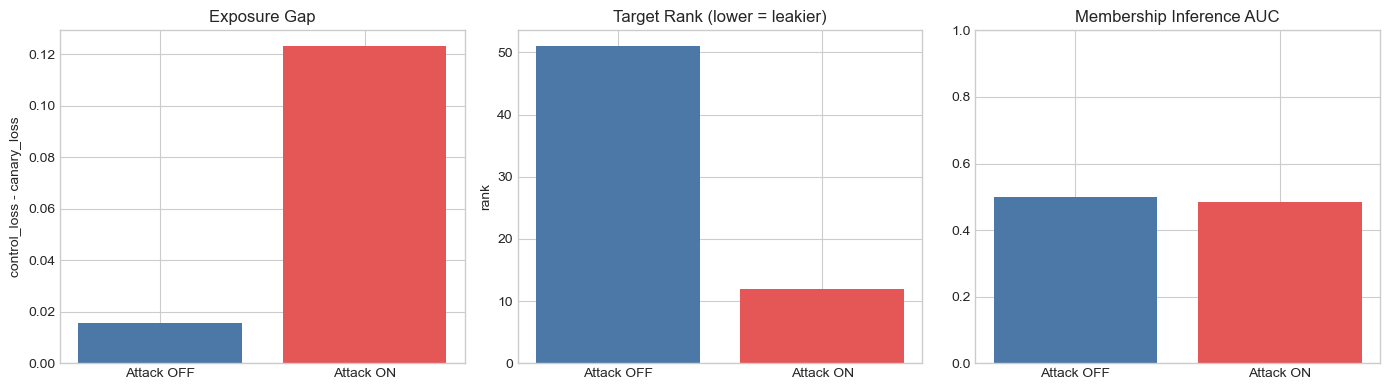

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_df = baseline_df.copy()
plot_df["label"] = plot_df["attack_enabled"].map({False: "Attack OFF", True: "Attack ON"})

axes[0].bar(plot_df["label"], plot_df["exposure_gap"], color=["#4C78A8", "#E45756"])
axes[0].set_title("Exposure Gap")
axes[0].set_ylabel("control_loss - canary_loss")

axes[1].bar(plot_df["label"], plot_df["target_rank"], color=["#4C78A8", "#E45756"])
axes[1].set_title("Target Rank (lower = leakier)")
axes[1].set_ylabel("rank")

axes[2].bar(plot_df["label"], plot_df["mi_auc"], color=["#4C78A8", "#E45756"])
axes[2].set_title("Membership Inference AUC")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 2) Tampering scale sweep

In [7]:
scales = [1.0, 1.2, 1.4, 1.6, 1.8]
rows = []

for s in scales:
    c = copy.deepcopy(cfg)
    c["attack"]["enabled"] = True
    c["attack"]["scale"] = s
    c["seed"] = int(cfg["seed"]) + int(s * 100)
    rows.append(run_tx_experiment(c))

sweep_df = pd.DataFrame(rows).sort_values("attack_scale")
sweep_df[["attack_scale", "exposure_gap", "target_rank", "mi_auc", "canary_loss", "control_loss"]]

,attack_scale,exposure_gap,target_rank,mi_auc,canary_loss,control_loss
0,1.0,0.041806,6,0.500000,4.818566,4.860371
1,1.2,0.022103,39,0.500000,4.842141,4.864244
2,1.4,0.263996,1,0.484375,4.563126,4.827123
3,1.6,-0.073015,85,0.484375,4.932401,4.859386
4,1.8,0.076480,19,0.515625,4.783467,4.859947


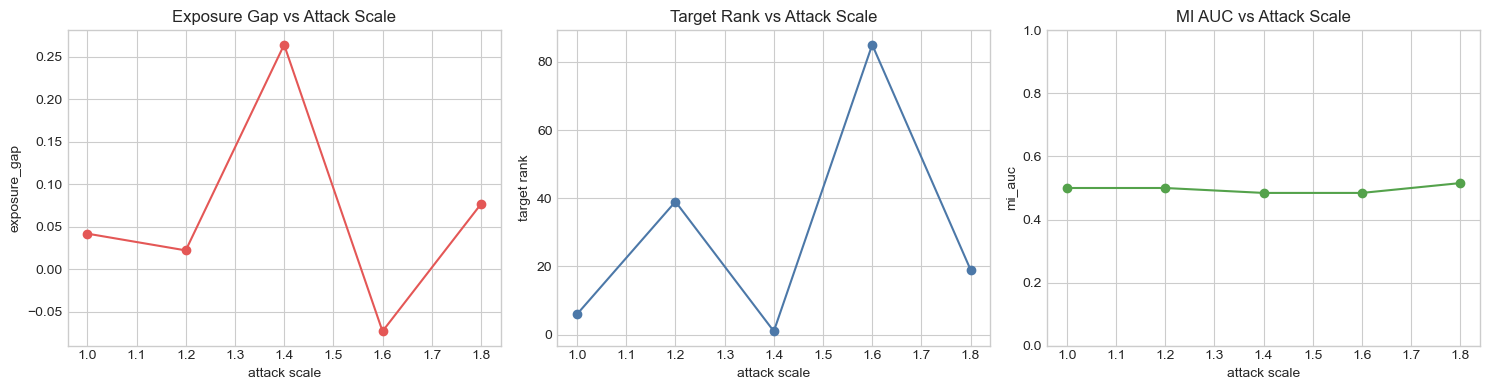

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sweep_df["attack_scale"], sweep_df["exposure_gap"], marker="o", color="#E45756")
axes[0].set_title("Exposure Gap vs Attack Scale")
axes[0].set_xlabel("attack scale")
axes[0].set_ylabel("exposure_gap")

axes[1].plot(sweep_df["attack_scale"], sweep_df["target_rank"], marker="o", color="#4C78A8")
axes[1].set_title("Target Rank vs Attack Scale")
axes[1].set_xlabel("attack scale")
axes[1].set_ylabel("target rank")

axes[2].plot(sweep_df["attack_scale"], sweep_df["mi_auc"], marker="o", color="#54A24B")
axes[2].set_title("MI AUC vs Attack Scale")
axes[2].set_xlabel("attack scale")
axes[2].set_ylabel("mi_auc")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [9]:
# Optional: persist outputs
os.makedirs("results", exist_ok=True)
baseline_df.to_csv("results/tx_fl_privacy_notebook_baseline.csv", index=False)
sweep_df.to_csv("results/tx_fl_privacy_notebook_sweep.csv", index=False)
print("Saved:")
print("- results/tx_fl_privacy_notebook_baseline.csv")
print("- results/tx_fl_privacy_notebook_sweep.csv")

Saved:
- results/tx_fl_privacy_notebook_baseline.csv
- results/tx_fl_privacy_notebook_sweep.csv


## 3) Quick interpretation template

Use this after running all cells:

- If **exposure_gap** increases under attack, canary leakage signal is stronger.
- If **target_rank** decreases under attack, canary continuation becomes easier to predict (leakier).
- **MI AUC** near `0.5` suggests weak membership separability in this setup; higher values indicate stronger membership inference signal.

You can extend this notebook by:
- repeating each setting over multiple seeds,
- adding confidence intervals,
- testing defenses (clipping, robust aggregation, differential privacy noise).